<a href="https://colab.research.google.com/github/SaanvikaVanga/FTI-DSRP-AI_Impact_Research/blob/main/Code_For_AI_Impact_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSRP AI Impact Research

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Data Cleaning + Initial Thoughts

In [ ]:
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/AI%20and%20Digital%20Media/Global_AI_Content_Impact_Dataset.csv"

df = pd.read_csv(url)
df.head(10)

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
6,Australia,2023,Media,68.23,6.14,6.20,53.13,53.16,Claude,Moderate,71.60,15.26
7,UK,2023,Gaming,91.27,33.87,41.67,56.26,59.93,ChatGPT,Moderate,46.98,28.51
8,Canada,2025,Education,17.02,87.77,4.59,52.45,64.72,Claude,Moderate,60.55,22.70
9,China,2025,Healthcare,25.50,18.74,15.07,40.81,64.86,Stable Diffusion,Moderate,51.07,39.97


In [ ]:
df.info() # no nulls
print()
print("Duplicate rows:", df.duplicated().sum()) # no duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [ ]:
# seperation of numerical columns and categorical columns

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_df = df[num_cols]
cat_df = df[cat_cols]

In [ ]:
num_df.describe()

,Year,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%)
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2022.315000,54.265850,46.07260,25.788250,39.719450,54.102150,59.425150,26.569550
std,1.825496,24.218067,29.16122,13.901105,23.829545,19.247079,17.319668,14.023729
min,2020.000000,10.530000,1.04000,0.090000,0.140000,20.210000,30.120000,1.180000
25%,2021.000000,33.222500,20.32250,14.995000,17.907500,37.770000,44.755000,14.052500
50%,2022.000000,53.310000,44.32000,25.735000,42.100000,54.515000,59.215000,27.390000
75%,2024.000000,76.220000,71.62000,37.417500,58.697500,69.402500,74.885000,38.432500
max,2025.000000,94.760000,99.06000,49.710000,79.550000,88.290000,89.880000,49.280000


In [ ]:
cat_df.describe()

,Country,Industry,Top AI Tools Used,Regulation Status
count,200,200,200,200
unique,10,10,7,3
top,India,Media,Midjourney,Moderate
freq,24,31,37,76




> This dataset, while having data from a significant amount of countries around the world, may not be the most accurate representation of global AI impact on commercial countries. This dataset fails to include data on industries based in South America, Africa, Eastern Europe, Central America, Southeast Asia, Central Asia, and many other regions.





> This dataset only reaches until 2025, not potraying the recent trends of AI adoption



# Exploratory Data Analysis

Univariate Analysis

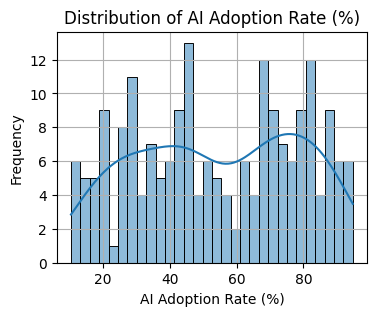

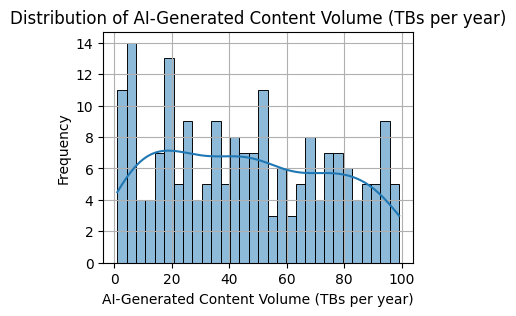

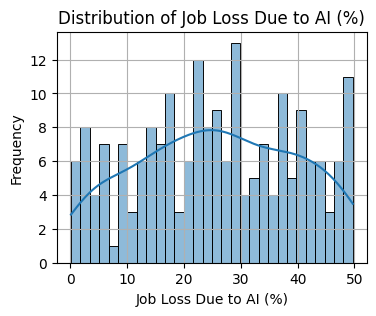

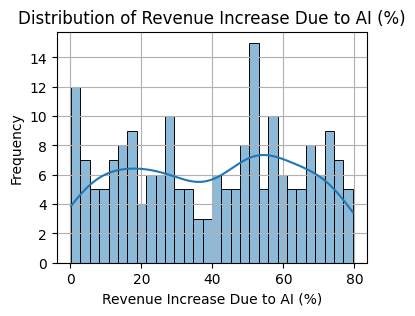

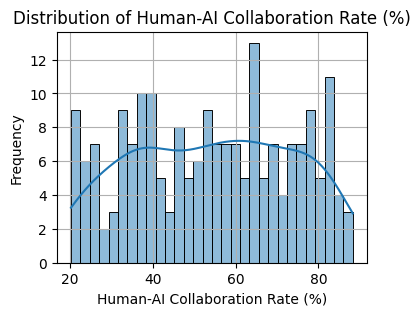

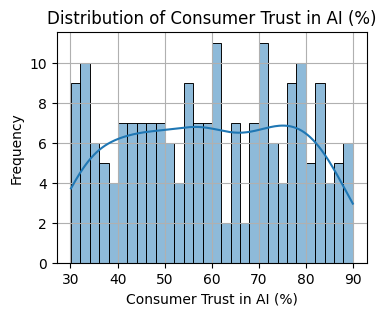

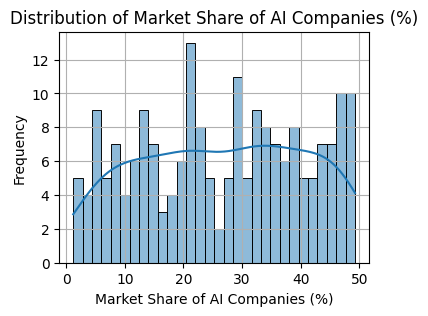

In [ ]:
for i in num_cols:
    if i == 'Year':
        continue
    plt.figure(figsize=(4, 3))
    sns.histplot(df[i], kde=True, bins=30)
    plt.grid(True)
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {i}')
    plt.show()

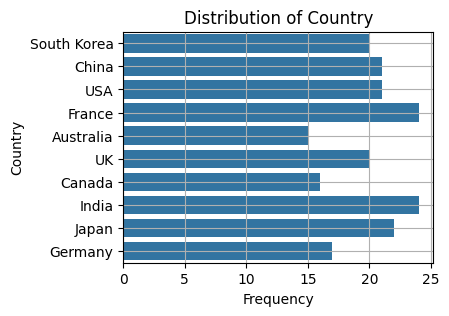

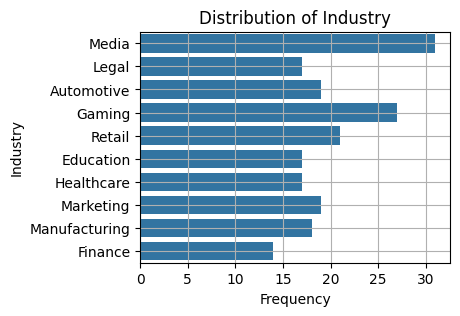

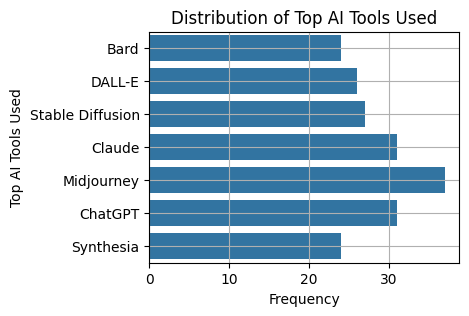

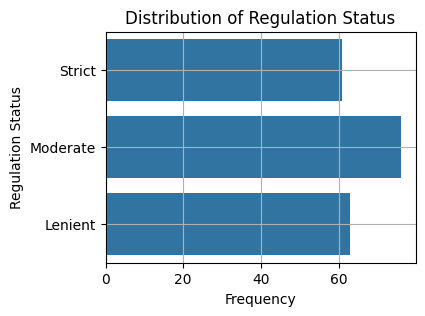

In [ ]:
for i in cat_cols:
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df, y=i)
    plt.grid(True)
    plt.xlabel('Frequency')
    plt.ylabel(i)
    plt.title(f'Distribution of {i}')
    plt.show()

Bivariate Analysis

1. What types of industries have the highest AI adoption rates?

In [ ]:
display(df["Industry"].value_counts())

total_rows = len(df)

for tool in df["Industry"].unique():
    tool_count = (df["Industry"] == tool).sum()
    tool_percent = (tool_count / total_rows) * 100
    print(f"{tool} = {tool_percent:.2f}% of df")

,count
Industry,
Media,31
Gaming,27
Retail,21
Automotive,19
Marketing,19
Manufacturing,18
Legal,17
Education,17
Healthcare,17


Media = 15.50% of df
Legal = 8.50% of df
Automotive = 9.50% of df
Gaming = 13.50% of df
Retail = 10.50% of df
Education = 8.50% of df
Healthcare = 8.50% of df
Marketing = 9.50% of df
Manufacturing = 9.00% of df
Finance = 7.00% of df


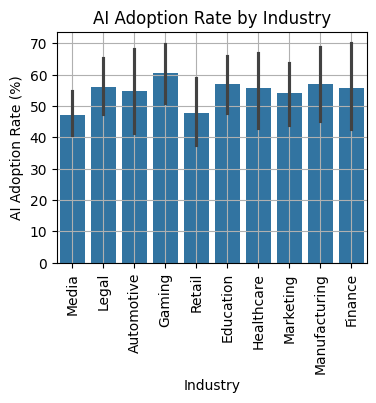

In [ ]:
plt.figure(figsize=(4, 3))
sns.barplot(data=df, x='Industry', y='AI Adoption Rate (%)')
plt.grid(True)
plt.xlabel('Industry')
plt.ylabel('AI Adoption Rate (%)')
plt.title('AI Adoption Rate by Industry')
plt.xticks(rotation=90)
plt.show()




> Gamimg industries are the second most occuring industry have the highest AI adoption rates out of other industries




Summary Table of Metrics by Industry:


,AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%)
Industry,,,,,,
Automotive,43.16,28.92,46.48,55.91,61.24,29.59
Education,60.82,26.14,39.54,58.88,51.65,22.84
Finance,37.54,27.79,36.26,53.61,56.18,29.00
Gaming,44.47,27.20,33.23,53.10,61.34,24.06
Healthcare,46.97,25.58,38.59,55.23,60.16,29.64
Legal,59.90,28.23,41.82,50.74,57.79,20.24
Manufacturing,49.81,32.75,42.81,55.97,58.27,25.96
Marketing,37.20,19.58,36.81,55.32,58.67,28.68
Media,38.17,22.75,43.72,49.98,61.76,30.03


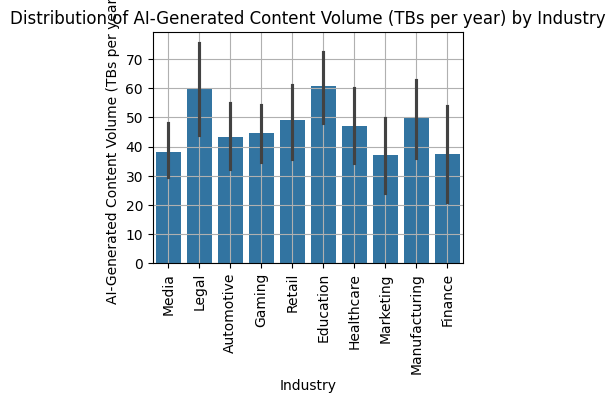

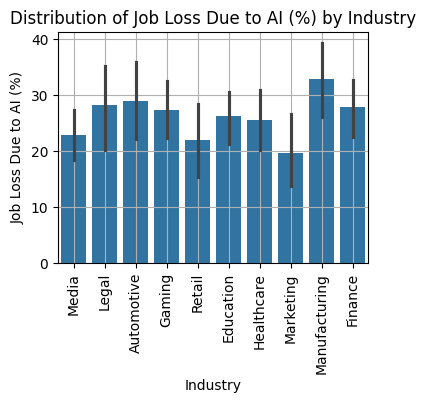

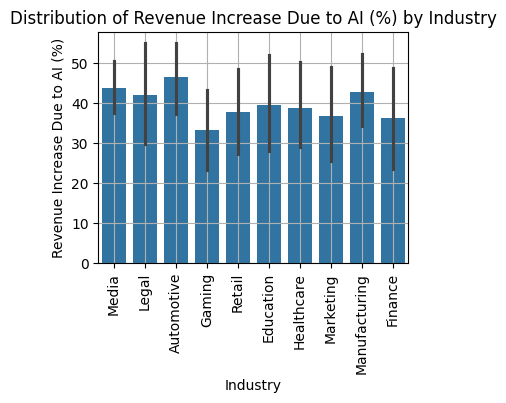

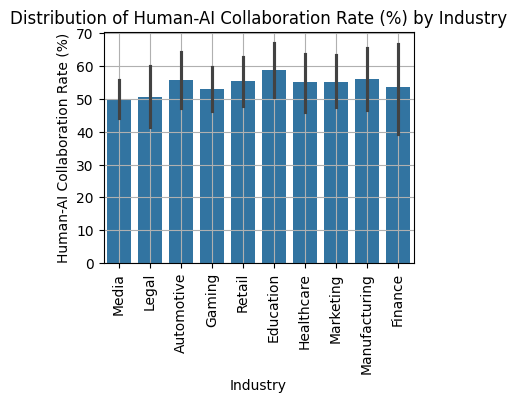

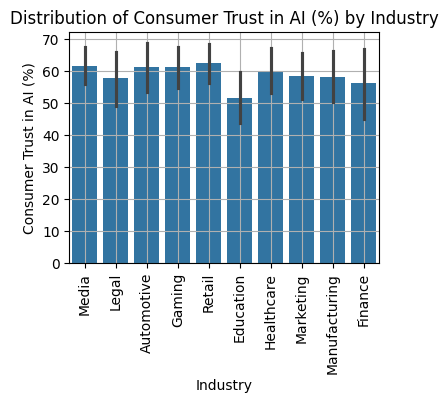

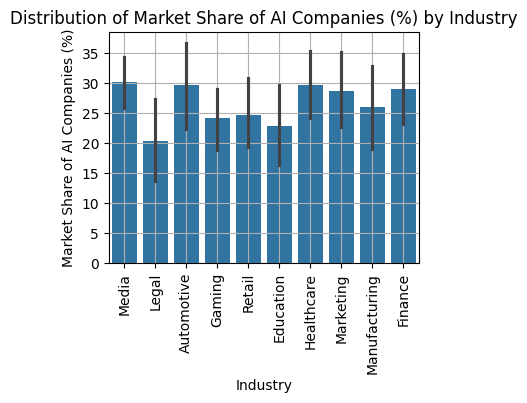

In [ ]:
num_cols_for_table = [col for col in num_cols if col not in ['Year', 'AI Adoption Rate (%)']]

for i in num_cols_for_table:
    plt.figure(figsize=(4, 3))
    sns.barplot(data=df, x='Industry', y=i)
    plt.grid(True)
    plt.xlabel('Industry')
    plt.ylabel(i)
    plt.title(f'Distribution of {i} by Industry')
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
industry_summary = df.groupby('Industry')[num_cols_for_table].mean().round(2)

print("\nSummary Table of Metrics by Industry:")
display(industry_summary)

In [ ]:
highest_lowest_data = []

for col in industry_summary.columns:
    highest_industry = industry_summary[col].idxmax()
    highest_value = industry_summary[col].max()
    lowest_industry = industry_summary[col].idxmin()
    lowest_value = industry_summary[col].min()

    highest_lowest_data.append({
        'Metric': col,
        'Highest Industry': highest_industry,
        'Highest Value': highest_value,
        'Lowest Industry': lowest_industry,
        'Lowest Value': lowest_value
    })

highest_lowest_df = pd.DataFrame(highest_lowest_data)

display(highest_lowest_df)

,Metric,Highest Industry,Highest Value,Lowest Industry,Lowest Value
0,AI-Generated Content Volume (TBs per year),Education,60.82,Marketing,37.20
1,Job Loss Due to AI (%),Manufacturing,32.75,Marketing,19.58
2,Revenue Increase Due to AI (%),Automotive,46.48,Gaming,33.23
3,Human-AI Collaboration Rate (%),Education,58.88,Media,49.98
4,Consumer Trust in AI (%),Retail,62.73,Education,51.65
5,Market Share of AI Companies (%),Media,30.03,Legal,20.24


In [ ]:
industry_summary.mean()

,0
AI-Generated Content Volume (TBs per year),46.712
Job Loss Due to AI (%),26.079
Revenue Increase Due to AI (%),39.694
Human-AI Collaboration Rate (%),54.415
Consumer Trust in AI (%),58.979
Market Share of AI Companies (%),26.464


In [ ]:
industry_summary.loc['Gaming']

,Gaming
AI-Generated Content Volume (TBs per year),44.47
Job Loss Due to AI (%),27.20
Revenue Increase Due to AI (%),33.23
Human-AI Collaboration Rate (%),53.10
Consumer Trust in AI (%),61.34
Market Share of AI Companies (%),24.06




> The gaming industry actually has the lowest revenue increase due to AI, and it could possibly be a good thing since it could be balancing out Job Loss, like how Manufacturing has high revenue increase due to AI and high Job Loss due to AI as well. In al the other sectors, Gaming has a pretty average score.



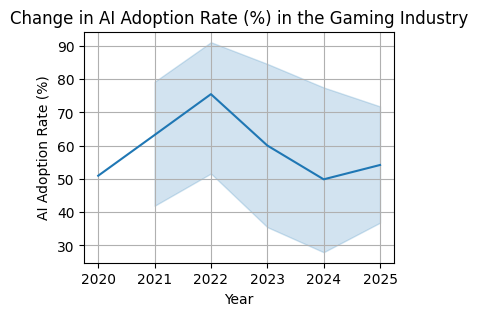

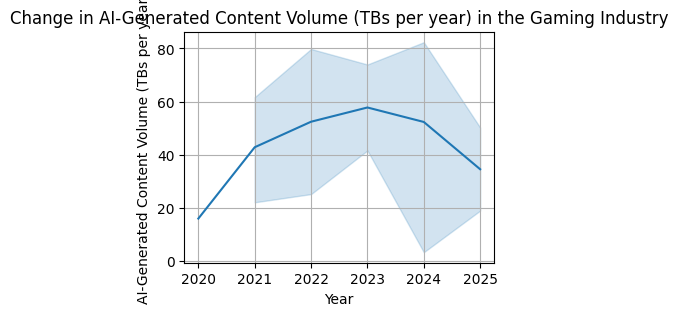

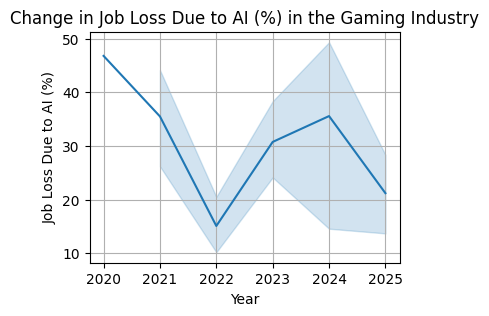

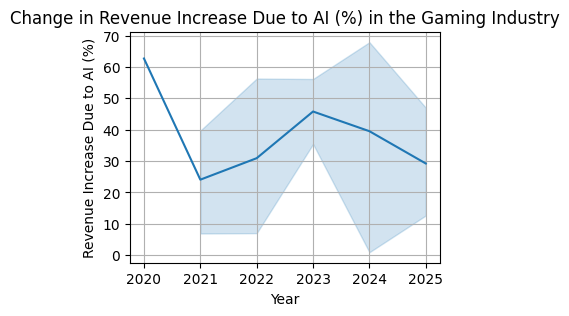

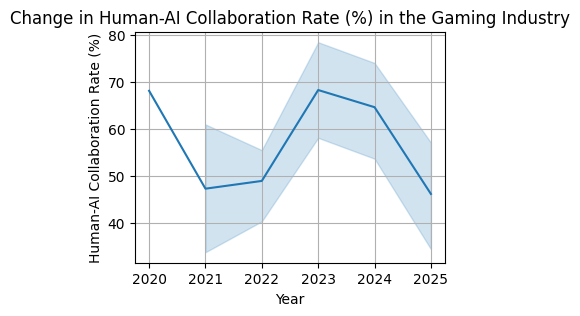

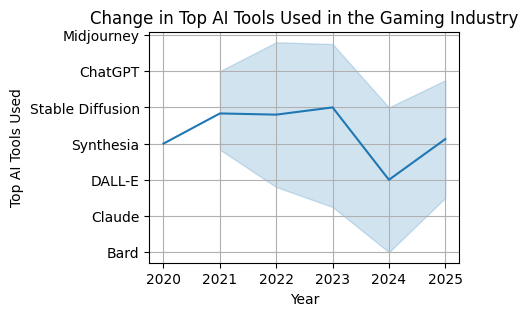

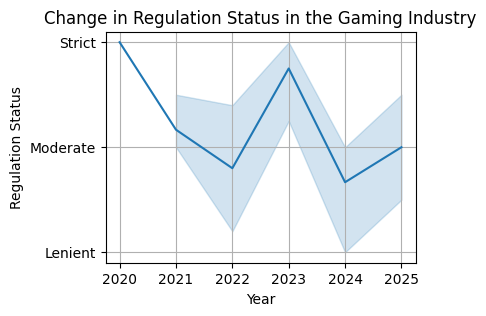

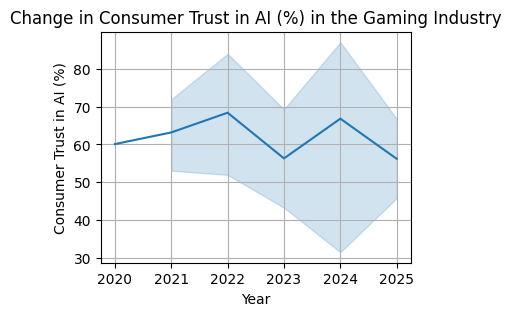

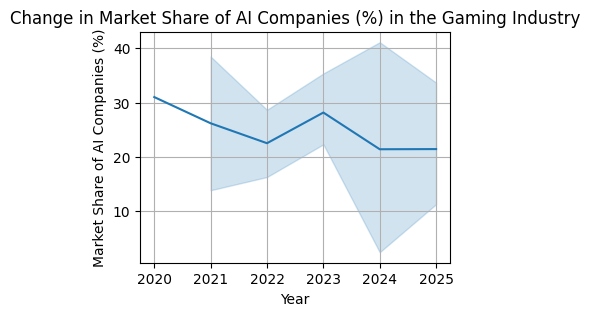

In [ ]:
gaming_df = df[df['Industry'] == 'Gaming']

tests = df.columns.tolist()
tests.remove('Industry')
tests.remove('Country')
tests.remove('Year')

for i in tests:
    plt.figure(figsize=(4, 3))
    sns.lineplot(data=gaming_df, x='Year', y=i)
    plt.title(f'Change in {i} in the Gaming Industry')
    plt.grid(True)
    plt.xlabel('Year')



> Human-AI collaboration rates and Revenue Increase line plots mimmic each other



2. What AI tools are most utillized in the gaming industry?

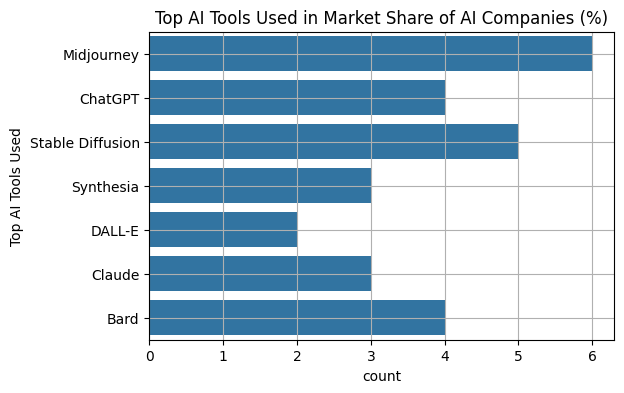

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=gaming_df, y='Top AI Tools Used')
plt.grid(True)
plt.ylabel('Top AI Tools Used')
plt.title(f'Top AI Tools Used in {i}')
plt.show()

In [ ]:
display(df["Top AI Tools Used"].value_counts())

total_rows = len(df)

for tool in df["Top AI Tools Used"].unique():
    tool_count = (df["Top AI Tools Used"] == tool).sum()
    tool_percent = (tool_count / total_rows) * 100
    print(f"{tool} = {tool_percent:.2f}% of df")

,count
Top AI Tools Used,
Midjourney,37
Claude,31
ChatGPT,31
Stable Diffusion,27
DALL-E,26
Bard,24
Synthesia,24


Bard = 12.00% of df
DALL-E = 13.00% of df
Stable Diffusion = 13.50% of df
Claude = 15.50% of df
Midjourney = 18.50% of df
ChatGPT = 15.50% of df
Synthesia = 12.00% of df


> Midjourney is the most poular model, and the most used in the Gaming industry

Changes over Time

['AI-Generated Content Volume (TBs per year)', 'Job Loss Due to AI (%)', 'Revenue Increase Due to AI (%)', 'Human-AI Collaboration Rate (%)', 'Consumer Trust in AI (%)', 'Market Share of AI Companies (%)']


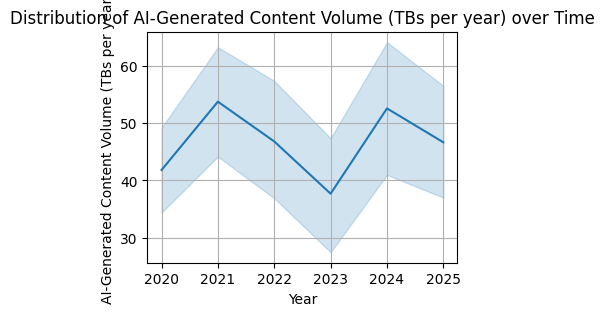

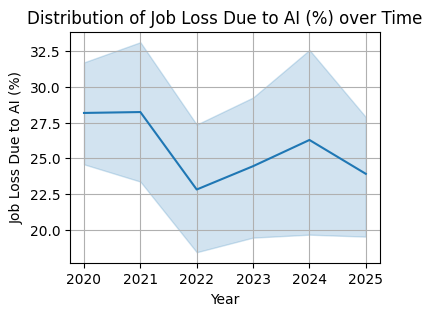

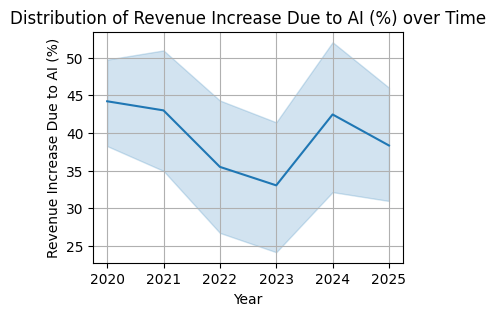

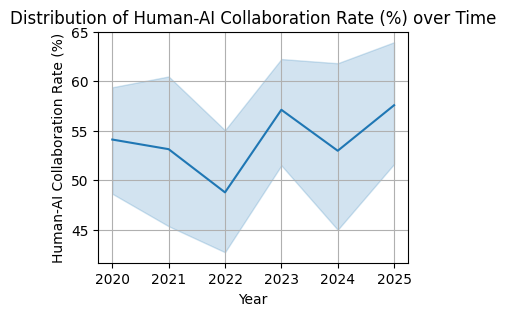

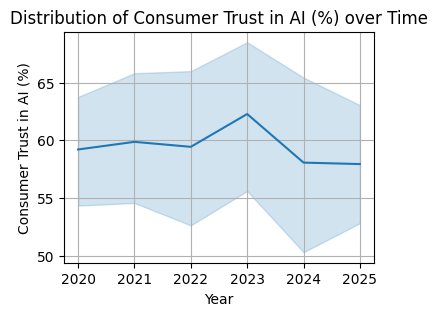

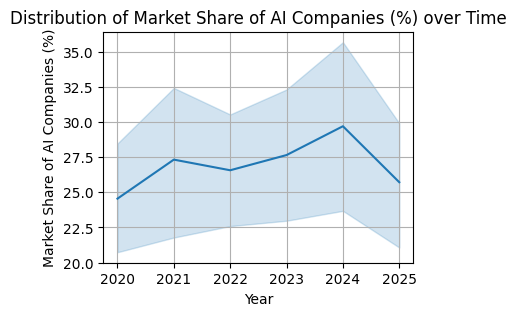

In [ ]:
cols = [col for col in num_cols if col != 'Year']
print(cols)

for i in cols:
    plt.figure(figsize=(4, 3))
    sns.lineplot(data=df, x='Year', y=i)
    plt.grid(True)
    plt.xlabel('Year')
    plt.ylabel(i)
    plt.title(f'Distribution of {i} over Time')
    plt.show()



> Even here, job loss, human-ai collaboration, and revenue increase are very similar.



**Summary of Findings**


*   Gaming has the highest AI adoption rate
*   Gaming has the lowest revenue increase due to AI
*   Other than that, Gaming has pretty average stats
*   Human-AI Collaboration seems very correlated with Revenue Increase Due to AI and Job Loss Due to AI




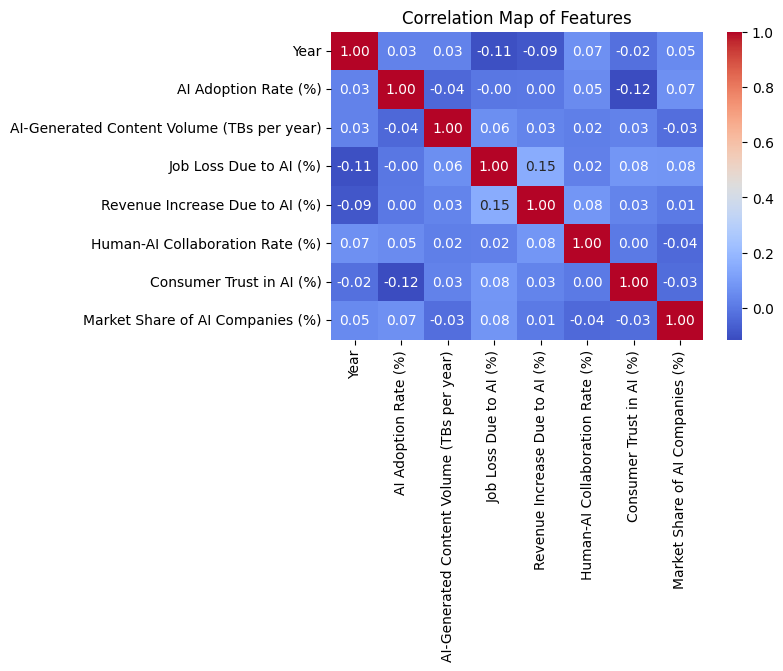

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Map of Features')
plt.show()

# Building and Training a Model

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Using Human-AI collaboration rate to predict Job Loss Due to AI

In [72]:
X = gaming_df[['AI Adoption Rate (%)']]
y = gaming_df['Job Loss Due to AI (%)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
y_pred = lin_reg_model.predict(X_test)
print("Linear Regression model")
print(f"MSE:", mean_squared_error( y_test, y_pred))
print("R2: ",r2_score(y_test, y_pred))
print("Coefficients:", lin_reg_model.coef_)
print("Intercept:",lin_reg_model.intercept_)
print()

Linear Regression model
MSE: 253.77885789772117
R2:  -2.4380241155584987
Coefficients: [-0.13516433]
Intercept: 38.20304641313328



In [73]:
y =  gaming_df['Revenue Increase Due to AI (%)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
y_pred = lin_reg_model.predict(X_test)
print("Linear Regression model")
print(f"MSE:", mean_squared_error( y_test, y_pred))
print("R2: ",r2_score(y_test, y_pred))
print("Coefficients:", lin_reg_model.coef_)
print("Intercept:",lin_reg_model.intercept_)

Linear Regression model
MSE: 920.4478948439483
R2:  -0.03689681972433645
Coefficients: [0.3627154]
Intercept: 12.299969308436285


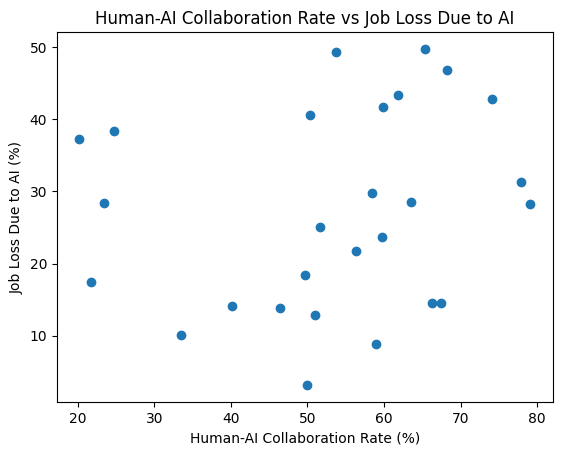

In [74]:
plt.scatter(gaming_df['Human-AI Collaboration Rate (%)'], gaming_df['Job Loss Due to AI (%)'])
plt.xlabel('Human-AI Collaboration Rate (%)')
plt.ylabel('Job Loss Due to AI (%)')
plt.title('Human-AI Collaboration Rate vs Job Loss Due to AI')
plt.show()

In [75]:
gaming_df.corr(numeric_only=True)


,Year,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%)
Year,1.000000,-0.187502,-0.057329,-0.284598,-0.010747,-0.042561,-0.160226,-0.146633
AI Adoption Rate (%),-0.187502,1.000000,-0.166807,-0.250313,0.297030,-0.002556,-0.302371,0.178127
AI-Generated Content Volume (TBs per year),-0.057329,-0.166807,1.000000,0.340091,-0.206722,0.082702,0.410658,-0.255893
Job Loss Due to AI (%),-0.284598,-0.250313,0.340091,1.000000,0.105952,0.192260,0.292506,-0.046223
Revenue Increase Due to AI (%),-0.010747,0.297030,-0.206722,0.105952,1.000000,0.214538,0.051534,0.173387
Human-AI Collaboration Rate (%),-0.042561,-0.002556,0.082702,0.192260,0.214538,1.000000,-0.054582,-0.093152
Consumer Trust in AI (%),-0.160226,-0.302371,0.410658,0.292506,0.051534,-0.054582,1.000000,-0.043963
Market Share of AI Companies (%),-0.146633,0.178127,-0.255893,-0.046223,0.173387,-0.093152,-0.043963,1.000000
